# 06 · PCA of Patch Features

Visualise the **patch-level** representations learned by AstroDINO.
For each image the ViT-B/8 encoder produces an **8×8 grid of patch tokens** (D=768).
We pool these across a mini-batch and run PCA to discover the low-dimensional structure.

**Key idea (from DINOv2):**
- **PC1** separates galaxy (foreground) from sky (background) → soft segmentation mask
- **PC2–4** encode semantic structure → map to RGB for a colourised patch visualisation

**Sections:**
1. Global configuration (same filter style as 03/04)
2. Dataset, model & patch token extraction
3. PCA eigenvalue spectrum
4. PC1 as foreground mask
5. RGB patch visualisation (PC2–4)
6. Per-morphology comparison

In [14]:
import os, sys, glob
import numpy as np
import h5py
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from omegaconf import OmegaConf
from sklearn.decomposition import PCA
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize

PROJECT_ROOT = '/u/yacheng/projects/ssl_outthere'
sys.path.insert(0, PROJECT_ROOT)
from dinov2.eval.setup import build_model_for_eval
from encoder_image.astrodino.train.data.augmentations import ToRGB

DEG_TO_PIXEL = 3600 * 1000 / 30   # 120 000 px/deg
MORPH_NAMES  = {0: 'Spheroid', 1: 'Disk-dom.', 2: 'Irregular', 3: 'Bulge-dom.'}
MORPH_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda:0


## 1 · Configuration
Same filter style as notebooks 03/04. Modify here and re-run.

In [15]:
MODEL_CONFIG  = '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb/config.yaml'
MODEL_WEIGHTS = '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb/eval/training_149999/teacher_checkpoint.pth'
MODEL_CONFIG  = '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_bs256/config.yaml'
MODEL_WEIGHTS = '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_bs256/eval/training_93999/teacher_checkpoint.pth'

MODEL_CONFIG  = '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_bs128/config.yaml'
MODEL_WEIGHTS = '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_bs128/eval/training_299999/teacher_checkpoint.pth'

DATA_ROOT     = '/u/yacheng/projects/ssl_outthere/images/jwst/f150w'

# ── FILTER OPTIONS (same as 03/04) ──────────────────────────────────────────
REFF_MIN_PIX       = 2.3
REFF_MAX_PIX       = 64
DELTA_THRESHOLD    = 0.5
AR_ERR_THRESH      = 0.05
RE_REL_ERR_THRESH  = 0.05
EXCLUDE_IRREGULAR  = True
# ────────────────────────────────────────────────────────────────────────────

# ── PCA CONFIG ───────────────────────────────────────────────────────────────
N_PCA_SAMPLES  = 5000    # galaxies used to fit PCA  (-1 = all)
N_COMPONENTS   = 16      # PCA components to keep
N_VIS_SAMPLES  = 12      # galaxies shown in the visualisation panels
BATCH_SIZE     = 128
SEED           = 42
# ────────────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(SEED)
print(f'Filters: reff∈[{REFF_MIN_PIX},{REFF_MAX_PIX}] px  delta<{DELTA_THRESHOLD}  excl_irr={EXCLUDE_IRREGULAR}')

Filters: reff∈[2.3,64] px  delta<0.5  excl_irr=True


## 2 · Dataset, Model & Patch Token Extraction

`model.forward_features(x)` returns a dict with `x_norm_patchtokens` of shape **(B, N_patches, D)**.
For crop_size=64, patch_size=8 → N_patches = 8×8 = 64.

In [16]:
class PatchDataset(Dataset):
    """Filtered galaxy dataset that returns (model_input, meta_tensor)."""

    def __init__(self, root, crop_size,
                 reff_min, reff_max, delta_threshold,
                 ar_err_thresh, re_rel_err_thresh,
                 max_samples, exclude_irregular=False, seed=42):
        self.to_rgb = ToRGB()
        self.crop   = transforms.CenterCrop(crop_size)
        _rng = np.random.default_rng(seed)

        self._files = []
        for fp in sorted(glob.glob(os.path.join(root, '*.h5'))):
            f = h5py.File(fp, 'r')
            if all(k in f for k in ['image', 'radius_sersic', 'axis_ratio', 'morph_flag_f150w']):
                self._files.append(f)
            else:
                f.close()
        print(f'Loaded {len(self._files)} files')

        self._idx = []   # (fi, li, log10_re_pix, ar, morph)
        for fi, f in enumerate(tqdm(self._files, desc='Indexing')):
            rs    = f['radius_sersic'][:]
            ar    = f['axis_ratio'][:]
            morph = f['morph_flag_f150w'][:]
            delta = f['delta_f150w'][:] if 'delta_f150w' in f else np.full(len(rs), np.nan)
            rs_err = f['radius_sersic_err'][:] if 'radius_sersic_err' in f else None
            ar_err = f['axis_ratio_err'][:]    if 'axis_ratio_err'    in f else None

            re_pix = rs * DEG_TO_PIXEL
            vmask  = (np.isfinite(rs) & (rs > 0) &
                      np.isfinite(ar) & (ar > 0.01) & (ar < 0.99) &
                      np.isfinite(morph) & np.isfinite(delta))

            if delta_threshold is not None: vmask &= delta < delta_threshold
            if reff_min is not None:        vmask &= np.isfinite(re_pix) & (re_pix >= reff_min)
            if reff_max is not None:        vmask &= np.isfinite(re_pix) & (re_pix <= reff_max)
            if ar_err is not None and ar_err_thresh is not None:
                vmask &= np.isfinite(ar_err) & np.isfinite(ar) & (ar > 0) & ((ar_err / ar) <= ar_err_thresh)
            if rs_err is not None and re_rel_err_thresh is not None:
                vmask &= np.isfinite(rs_err) & np.isfinite(rs) & (rs > 0) & ((rs_err / rs) <= re_rel_err_thresh)
            if exclude_irregular:
                vmask &= (morph != 2)

            for li in np.where(vmask)[0]:
                log_r = np.log10(float(rs[li]) * DEG_TO_PIXEL)
                self._idx.append((fi, li, log_r, float(ar[li]), int(morph[li])))

        print(f'Valid samples: {len(self._idx)}'
              + (' (Irregular excluded)' if exclude_irregular else ''))
        if max_samples > 0 and max_samples < len(self._idx):
            chosen = _rng.choice(len(self._idx), size=max_samples, replace=False)
            self._idx = [self._idx[i] for i in chosen]
            print(f'Subsampled to {len(self._idx)}')

    def __len__(self): return len(self._idx)

    def __getitem__(self, i):
        fi, li, log_r, ar, morph = self._idx[i]
        img  = self._files[fi]['image'][li].astype('float32')
        img3 = np.repeat(img[np.newaxis], 3, axis=0)
        t    = self.crop(torch.from_numpy(img3))
        t    = torch.from_numpy(self.to_rgb(t.numpy()))
        meta = torch.tensor([log_r, ar, float(morph)], dtype=torch.float32)
        return t, meta

    def get_display_image(self, i):
        fi, li, _, _, _ = self._idx[i]
        img = self._files[fi]['image'][li].astype('float32')
        return self.crop(torch.from_numpy(img[np.newaxis])).squeeze(0).numpy()

    def get_meta(self, i):
        _, _, log_r, ar, morph = self._idx[i]
        return {'log10_re_pix': log_r, 'axis_ratio': ar, 'morph': morph,
                'morph_name': MORPH_NAMES.get(morph, str(morph))}

    def close(self):
        for f in self._files:
            try: f.close()
            except: pass


cfg   = OmegaConf.load(MODEL_CONFIG)
model = build_model_for_eval(cfg, pretrained_weights=MODEL_WEIGHTS)
model = model.to(DEVICE).eval()

CROP_SIZE  = cfg.crops.global_crops_size
PATCH_SIZE = cfg.student.patch_size
N_PATCHES  = (CROP_SIZE // PATCH_SIZE) ** 2
PATCH_GRID = CROP_SIZE // PATCH_SIZE
D          = model.embed_dim

print(f'Model: ViT-{cfg.student.arch[-1].upper()} | crop={CROP_SIZE}px | '
      f'patch={PATCH_SIZE}px | grid={PATCH_GRID}×{PATCH_GRID} | D={D}')

ds = PatchDataset(
    DATA_ROOT, CROP_SIZE,
    reff_min=REFF_MIN_PIX, reff_max=REFF_MAX_PIX,
    delta_threshold=DELTA_THRESHOLD,
    ar_err_thresh=AR_ERR_THRESH,
    re_rel_err_thresh=RE_REL_ERR_THRESH,
    max_samples=N_PCA_SAMPLES,
    exclude_irregular=EXCLUDE_IRREGULAR,
    seed=SEED
)
print(f'Dataset: {len(ds)} samples')

Model: ViT-E | crop=72px | patch=6px | grid=12×12 | D=512
Loaded 20 files


Indexing: 100%|██████████| 20/20 [00:00<00:00, 78.28it/s]

Valid samples: 18754 (Irregular excluded)
Subsampled to 5000
Dataset: 5000 samples


In [17]:
# ── Extract patch tokens for the full PCA dataset ────────────────────────────
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=4, pin_memory=True)

all_patches = []   # list of (B, N_patches, D) arrays
all_meta    = []   # list of (B, 3) arrays  [log_re, ar, morph]

with torch.no_grad():
    for imgs, meta in tqdm(loader, desc='Extracting patch tokens'):
        imgs = imgs.to(DEVICE)
        out  = model.forward_features(imgs)
        patch_tokens = out['x_norm_patchtokens']  # (B, N_patches, D)
        all_patches.append(patch_tokens.cpu().numpy())
        all_meta.append(meta.numpy())

patch_bank = np.concatenate(all_patches, axis=0)   # (N, N_patches, D)
meta_bank  = np.concatenate(all_meta,    axis=0)   # (N, 3)

log_re_all = meta_bank[:, 0]
ar_all     = meta_bank[:, 1]
morph_all  = meta_bank[:, 2].astype(int)

N = patch_bank.shape[0]
print(f'patch_bank: {patch_bank.shape}  →  {N} galaxies × {N_PATCHES} patches × {D} dims')

# Flatten to (N * N_patches, D) for PCA
patches_flat = patch_bank.reshape(-1, D)   # (N*N_patches, D)
print(f'patches_flat: {patches_flat.shape}')

Extracting patch tokens: 100%|██████████| 40/40 [00:19<00:00,  2.01it/s]


patch_bank: (5000, 144, 512)  →  5000 galaxies × 144 patches × 512 dims
patches_flat: (720000, 512)


## 3 · PCA Eigenvalue Spectrum

How much of the patch-feature variance is captured by the first few PCs?

PCA fitted on 720,000 patches
Variance explained — PC1:18.36%  PC1-3:39.09%  PC1-16:67.77%


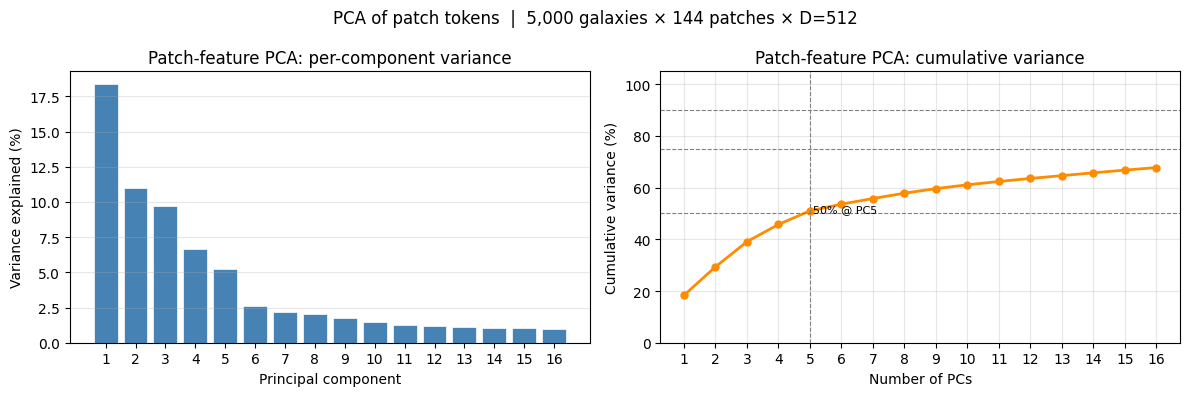

In [18]:
pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
patches_pca = pca.fit_transform(patches_flat)   # (N*N_patches, N_COMPONENTS)

ev_ratio = pca.explained_variance_ratio_
ev_cum   = np.cumsum(ev_ratio)

print(f'PCA fitted on {patches_flat.shape[0]:,} patches')
print(f'Variance explained — PC1:{ev_ratio[0]:.2%}  '
      f'PC1-3:{ev_cum[2]:.2%}  PC1-{N_COMPONENTS}:{ev_cum[-1]:.2%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bars = ax.bar(range(1, N_COMPONENTS + 1), ev_ratio * 100,
              color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Principal component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Patch-feature PCA: per-component variance')
ax.set_xticks(range(1, N_COMPONENTS + 1))
ax.grid(True, axis='y', alpha=0.3)

ax2 = axes[1]
ax2.plot(range(1, N_COMPONENTS + 1), ev_cum * 100, 'o-', ms=5, lw=2, color='darkorange')
for thresh in [50, 75, 90]:
    idx = np.searchsorted(ev_cum, thresh / 100)
    ax2.axhline(thresh, color='gray', lw=0.8, ls='--')
    if idx < N_COMPONENTS:
        ax2.axvline(idx + 1, color='gray', lw=0.8, ls='--')
        ax2.text(idx + 1.1, thresh + 0.5, f'{thresh}% @ PC{idx+1}', fontsize=8)
ax2.set_xlabel('Number of PCs')
ax2.set_ylabel('Cumulative variance (%)')
ax2.set_title('Patch-feature PCA: cumulative variance')
ax2.set_xticks(range(1, N_COMPONENTS + 1))
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'PCA of patch tokens  |  {N:,} galaxies × {N_PATCHES} patches × D={D}',
             fontsize=12)
plt.tight_layout()
plt.show()

## 4 · PC1 as Foreground / Background Mask

In DINOv2, the **first principal component** of patch features separates foreground (galaxy) from background (sky).
We use a simple sign-threshold on PC1 to produce a soft segmentation mask.

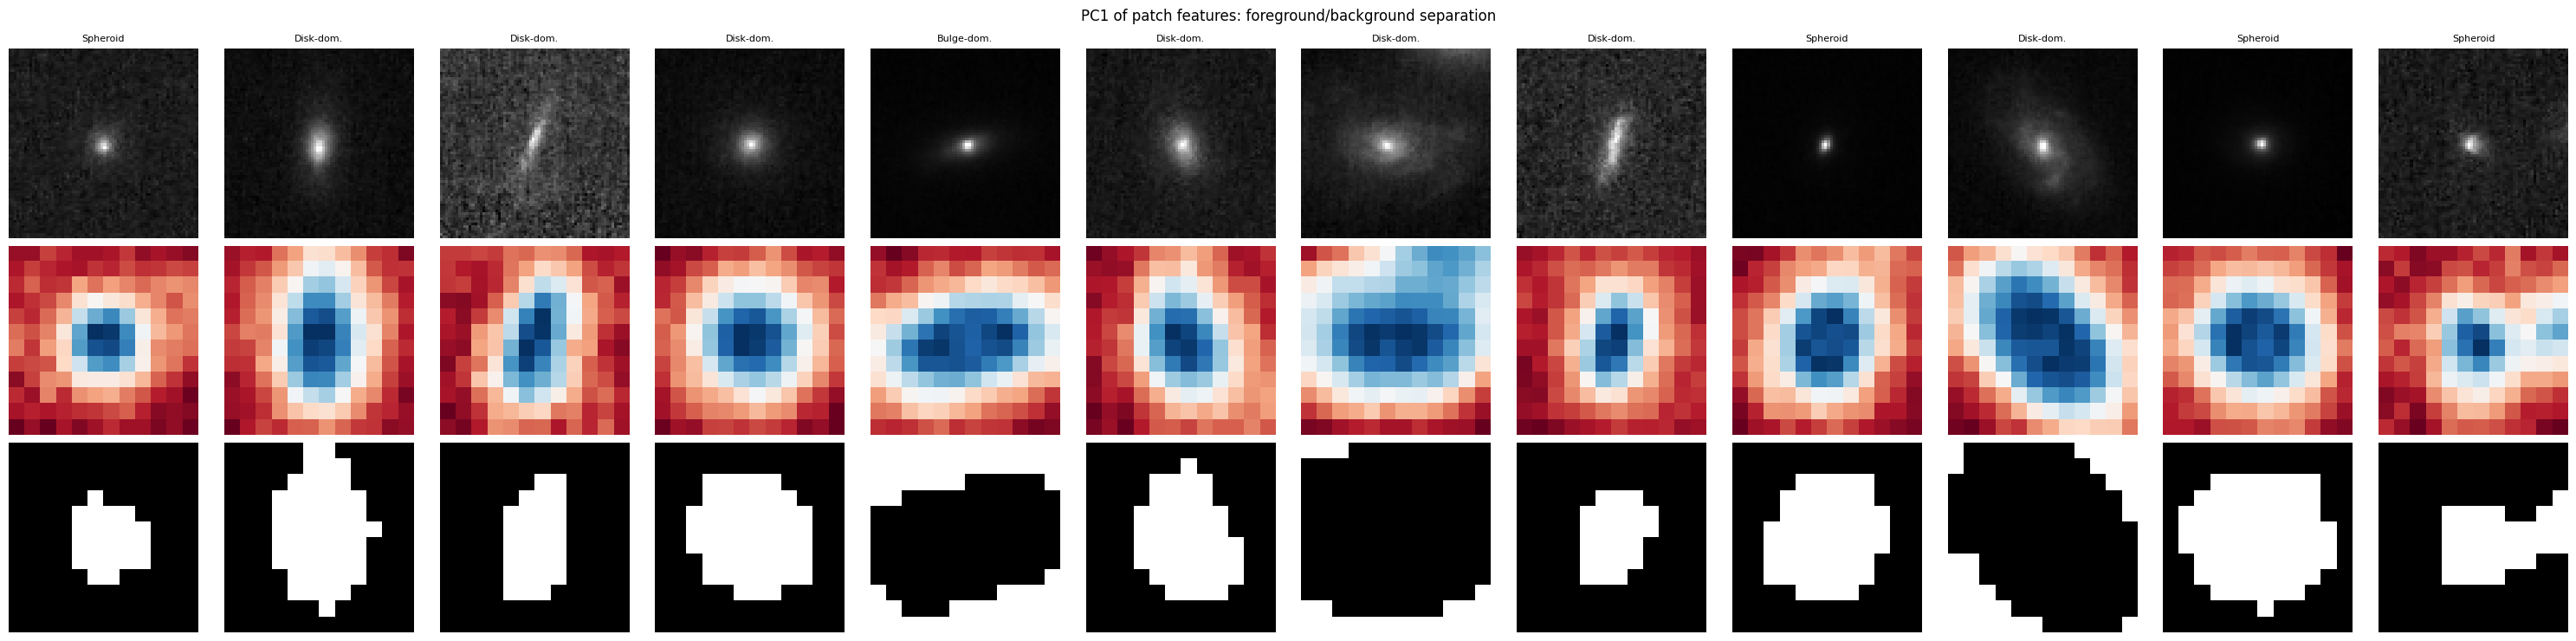

In [19]:
# ── Sample N_VIS_SAMPLES random galaxies for visual panels ───────────────────
vis_idx = rng.choice(N, size=min(N_VIS_SAMPLES, N), replace=False)

# Reshape PCA outputs back to per-galaxy grids
# patches_pca: (N*N_patches, N_COMPONENTS)
patches_pca_3d = patches_pca.reshape(N, N_PATCHES, N_COMPONENTS)   # (N, 64, K)


def make_pc1_mask(pc1_map: np.ndarray, positive_fg: bool = True) -> np.ndarray:
    """Threshold PC1 values to produce a binary foreground mask.
    pc1_map: (PATCH_GRID, PATCH_GRID) array of PC1 scores.
    The sign convention may flip between runs; we pick the side that is the minority
    (galaxy typically covers fewer patches than sky background).
    """
    thresh = 0.0
    pos_frac = (pc1_map > thresh).mean()
    # foreground is the minority region
    if pos_frac < 0.5:
        return pc1_map > thresh   # positive side is fg
    else:
        return pc1_map < thresh   # negative side is fg


n_cols   = N_VIS_SAMPLES
fig, axes = plt.subplots(3, n_cols, figsize=(2.5 * n_cols, 7.5))
row_labels = ['Galaxy (gray)', 'PC1 score', 'FG mask']

for col, gi in enumerate(vis_idx):
    img   = ds.get_display_image(int(gi))
    meta  = ds.get_meta(int(gi))
    pc1_g = patches_pca_3d[gi, :, 0].reshape(PATCH_GRID, PATCH_GRID)
    mask  = make_pc1_mask(pc1_g)

    # Row 0: original galaxy
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(meta['morph_name'], fontsize=8)
    axes[0, col].axis('off')

    # Row 1: PC1 heatmap (upsampled for visibility)
    axes[1, col].imshow(pc1_g, cmap='RdBu_r', interpolation='nearest')
    axes[1, col].axis('off')

    # Row 2: binary foreground mask
    axes[2, col].imshow(mask.astype(float), cmap='Greys_r', vmin=0, vmax=1,
                        interpolation='nearest')
    axes[2, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=90, labelpad=4)

plt.suptitle('PC1 of patch features: foreground/background separation', fontsize=12)
plt.tight_layout()
plt.show()

## 5 · RGB Patch Visualisation (PC2–4)

Assign PC2→R, PC3→G, PC4→B (normalised per-image) to produce a semantic colour map of each galaxy.
Similar patches (same learned structure) will appear in the same colour.

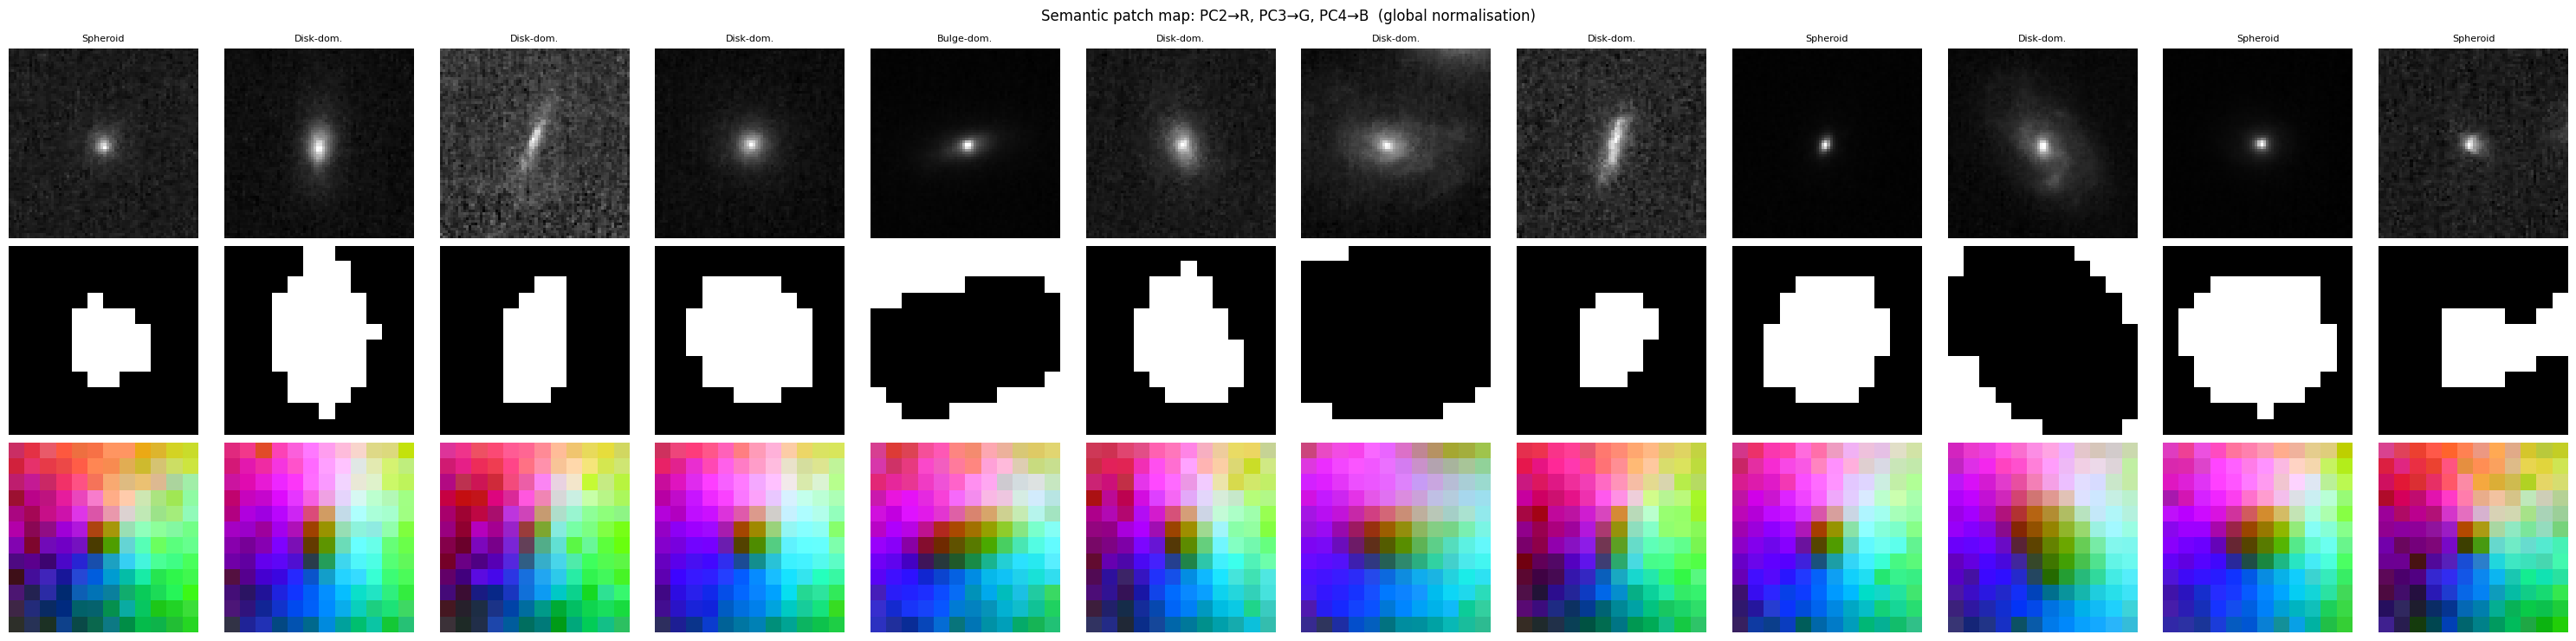

In [20]:
def make_rgb_map(pca_grid: np.ndarray, pc_indices=(1, 2, 3)) -> np.ndarray:
    """Build an RGB image from three PCA channels.
    pca_grid: (PATCH_GRID, PATCH_GRID, N_COMPONENTS)
    Returns uint8 (PATCH_GRID, PATCH_GRID, 3).
    """
    rgb = np.stack([pca_grid[:, :, c] for c in pc_indices], axis=-1)  # (G, G, 3)
    # Normalise each channel independently to [0, 1] using dataset-wide percentiles
    for ch in range(3):
        lo, hi = np.percentile(rgb[:, :, ch], [5, 95])
        if hi > lo:
            rgb[:, :, ch] = np.clip((rgb[:, :, ch] - lo) / (hi - lo), 0, 1)
        else:
            rgb[:, :, ch] = 0.5
    return (rgb * 255).astype(np.uint8)


# ── Compute dataset-wide percentiles for consistent colour scaling ────────────
# patches_pca_3d: (N, N_patches, K)  →  reshape to (N, PATCH_GRID, PATCH_GRID, K)
pca_grids = patches_pca_3d.reshape(N, PATCH_GRID, PATCH_GRID, N_COMPONENTS)

# Percentile bounds computed over all galaxies for PCs 2-4 (indices 1-3)
pc_bounds = {}
for ch_idx, pc_idx in enumerate([1, 2, 3]):
    vals = pca_grids[:, :, :, pc_idx].ravel()
    pc_bounds[pc_idx] = (np.percentile(vals, 5), np.percentile(vals, 95))


def make_rgb_map_global(pca_grid_2d: np.ndarray, pc_indices=(1, 2, 3)) -> np.ndarray:
    """Same as make_rgb_map but uses dataset-wide normalisation for consistency."""
    rgb = np.stack([pca_grid_2d[:, :, c] for c in pc_indices], axis=-1).astype(float)
    for ch, pc_idx in enumerate(pc_indices):
        lo, hi = pc_bounds[pc_idx]
        rgb[:, :, ch] = np.clip((rgb[:, :, ch] - lo) / (hi - lo + 1e-8), 0, 1)
    return (rgb * 255).astype(np.uint8)


# ── Visualise: galaxy | PC1 mask | RGB patch map (2 row layout) ──────────────
fig, axes = plt.subplots(3, n_cols, figsize=(2.5 * n_cols, 7.5))
row_labels = ['Galaxy (gray)', 'FG mask (PC1)', 'Semantic RGB (PC2-4)']

for col, gi in enumerate(vis_idx):
    img      = ds.get_display_image(int(gi))
    meta     = ds.get_meta(int(gi))
    grid_i   = pca_grids[gi]                      # (PATCH_GRID, PATCH_GRID, K)
    pc1_g    = grid_i[:, :, 0]
    mask     = make_pc1_mask(pc1_g)
    rgb_map  = make_rgb_map_global(grid_i)

    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(meta['morph_name'], fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(mask.astype(float), cmap='Greys_r', vmin=0, vmax=1,
                        interpolation='nearest')
    axes[1, col].axis('off')

    axes[2, col].imshow(rgb_map, interpolation='nearest')
    axes[2, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9)

plt.suptitle('Semantic patch map: PC2→R, PC3→G, PC4→B  (global normalisation)', fontsize=12)
plt.tight_layout()
plt.show()

## 6 · Per-Morphology Comparison

Do different morphological classes occupy distinct regions of patch PCA space?

- **6a** Average PC1–4 maps per morphology class
- **6b** Distribution of PC1–4 scores across morphologies
- **6c** Gallery: one example per morphology class

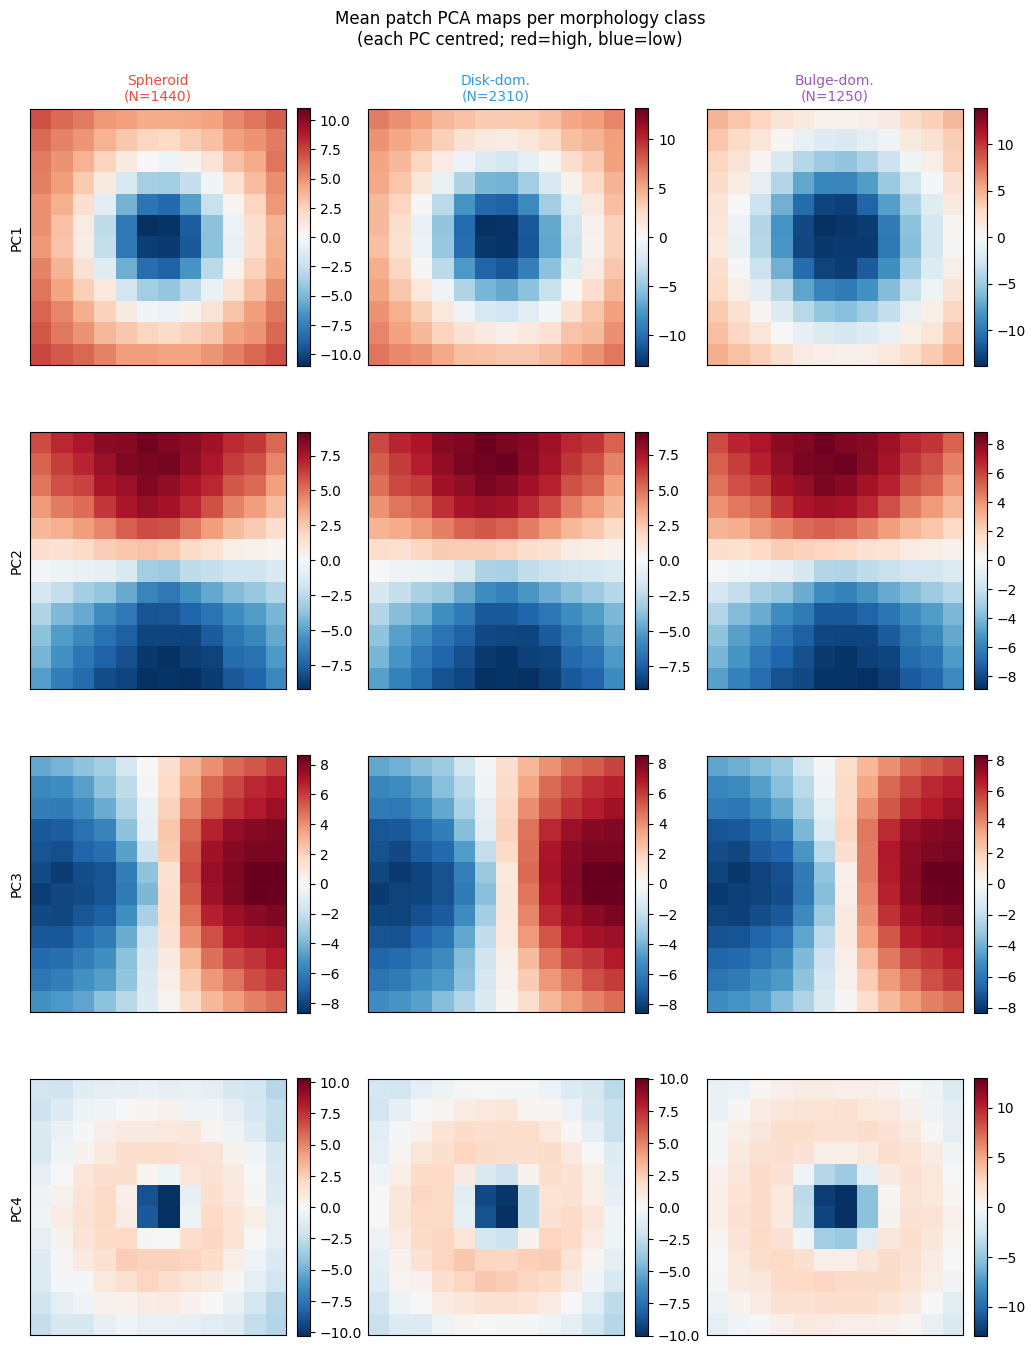

In [21]:
# ── 6a: Mean PCA maps per morphology ─────────────────────────────────────────
present_classes = sorted(np.unique(morph_all))
N_PC_SHOW       = 4

fig, axes = plt.subplots(N_PC_SHOW, len(present_classes),
                         figsize=(3.5 * len(present_classes), 3.5 * N_PC_SHOW))

for col, c in enumerate(present_classes):
    mask_c   = morph_all == c
    grids_c  = pca_grids[mask_c]                        # (Nc, G, G, K)
    mean_map = grids_c.mean(axis=0)                     # (G, G, K)

    for row in range(N_PC_SHOW):
        ax  = axes[row, col]
        val = mean_map[:, :, row]
        vabs = np.abs(val).max()
        im  = ax.imshow(val, cmap='RdBu_r', vmin=-vabs, vmax=vabs,
                        interpolation='nearest')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if row == 0:
            ax.set_title(f'{MORPH_NAMES.get(c, c)}\n(N={mask_c.sum()})',
                         color=MORPH_COLORS[c], fontsize=10)
        if col == 0:
            ax.set_ylabel(f'PC{row + 1}', fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Mean patch PCA maps per morphology class\n(each PC centred; red=high, blue=low)',
             fontsize=12)
plt.tight_layout()
plt.show()

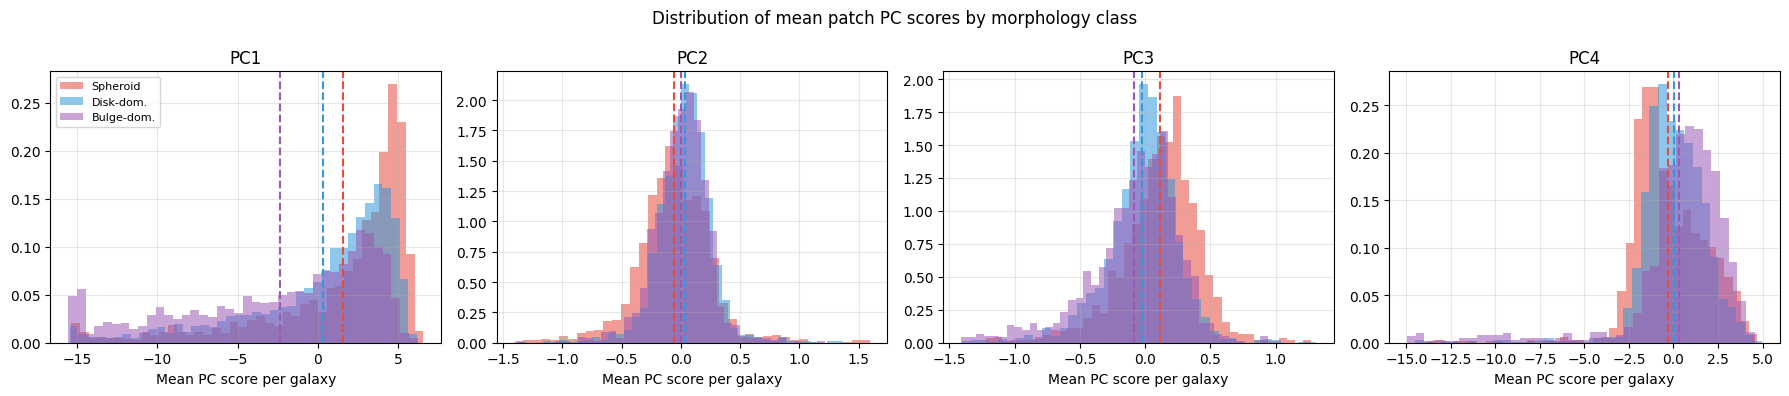

In [22]:
# ── 6b: Score distributions across morphologies (per PC) ─────────────────────
# We use the mean PC score per galaxy (aggregated over its 64 patches)
# shape: (N, K)
galaxy_pc_means = pca_grids.reshape(N, N_PATCHES, N_COMPONENTS).mean(axis=1)

fig, axes = plt.subplots(1, N_PC_SHOW, figsize=(4.5 * N_PC_SHOW, 4), sharey=False)

for ax, pc_idx in zip(axes, range(N_PC_SHOW)):
    for c in present_classes:
        vals = galaxy_pc_means[morph_all == c, pc_idx]
        ax.hist(vals, bins=40, alpha=0.55, density=True,
                label=MORPH_NAMES.get(c, c), color=MORPH_COLORS[c], edgecolor='none')
        ax.axvline(vals.mean(), color=MORPH_COLORS[c], lw=1.5, ls='--')
    ax.set_xlabel('Mean PC score per galaxy')
    ax.set_title(f'PC{pc_idx + 1}')
    if pc_idx == 0:
        ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of mean patch PC scores by morphology class', fontsize=12)
plt.tight_layout()
plt.show()

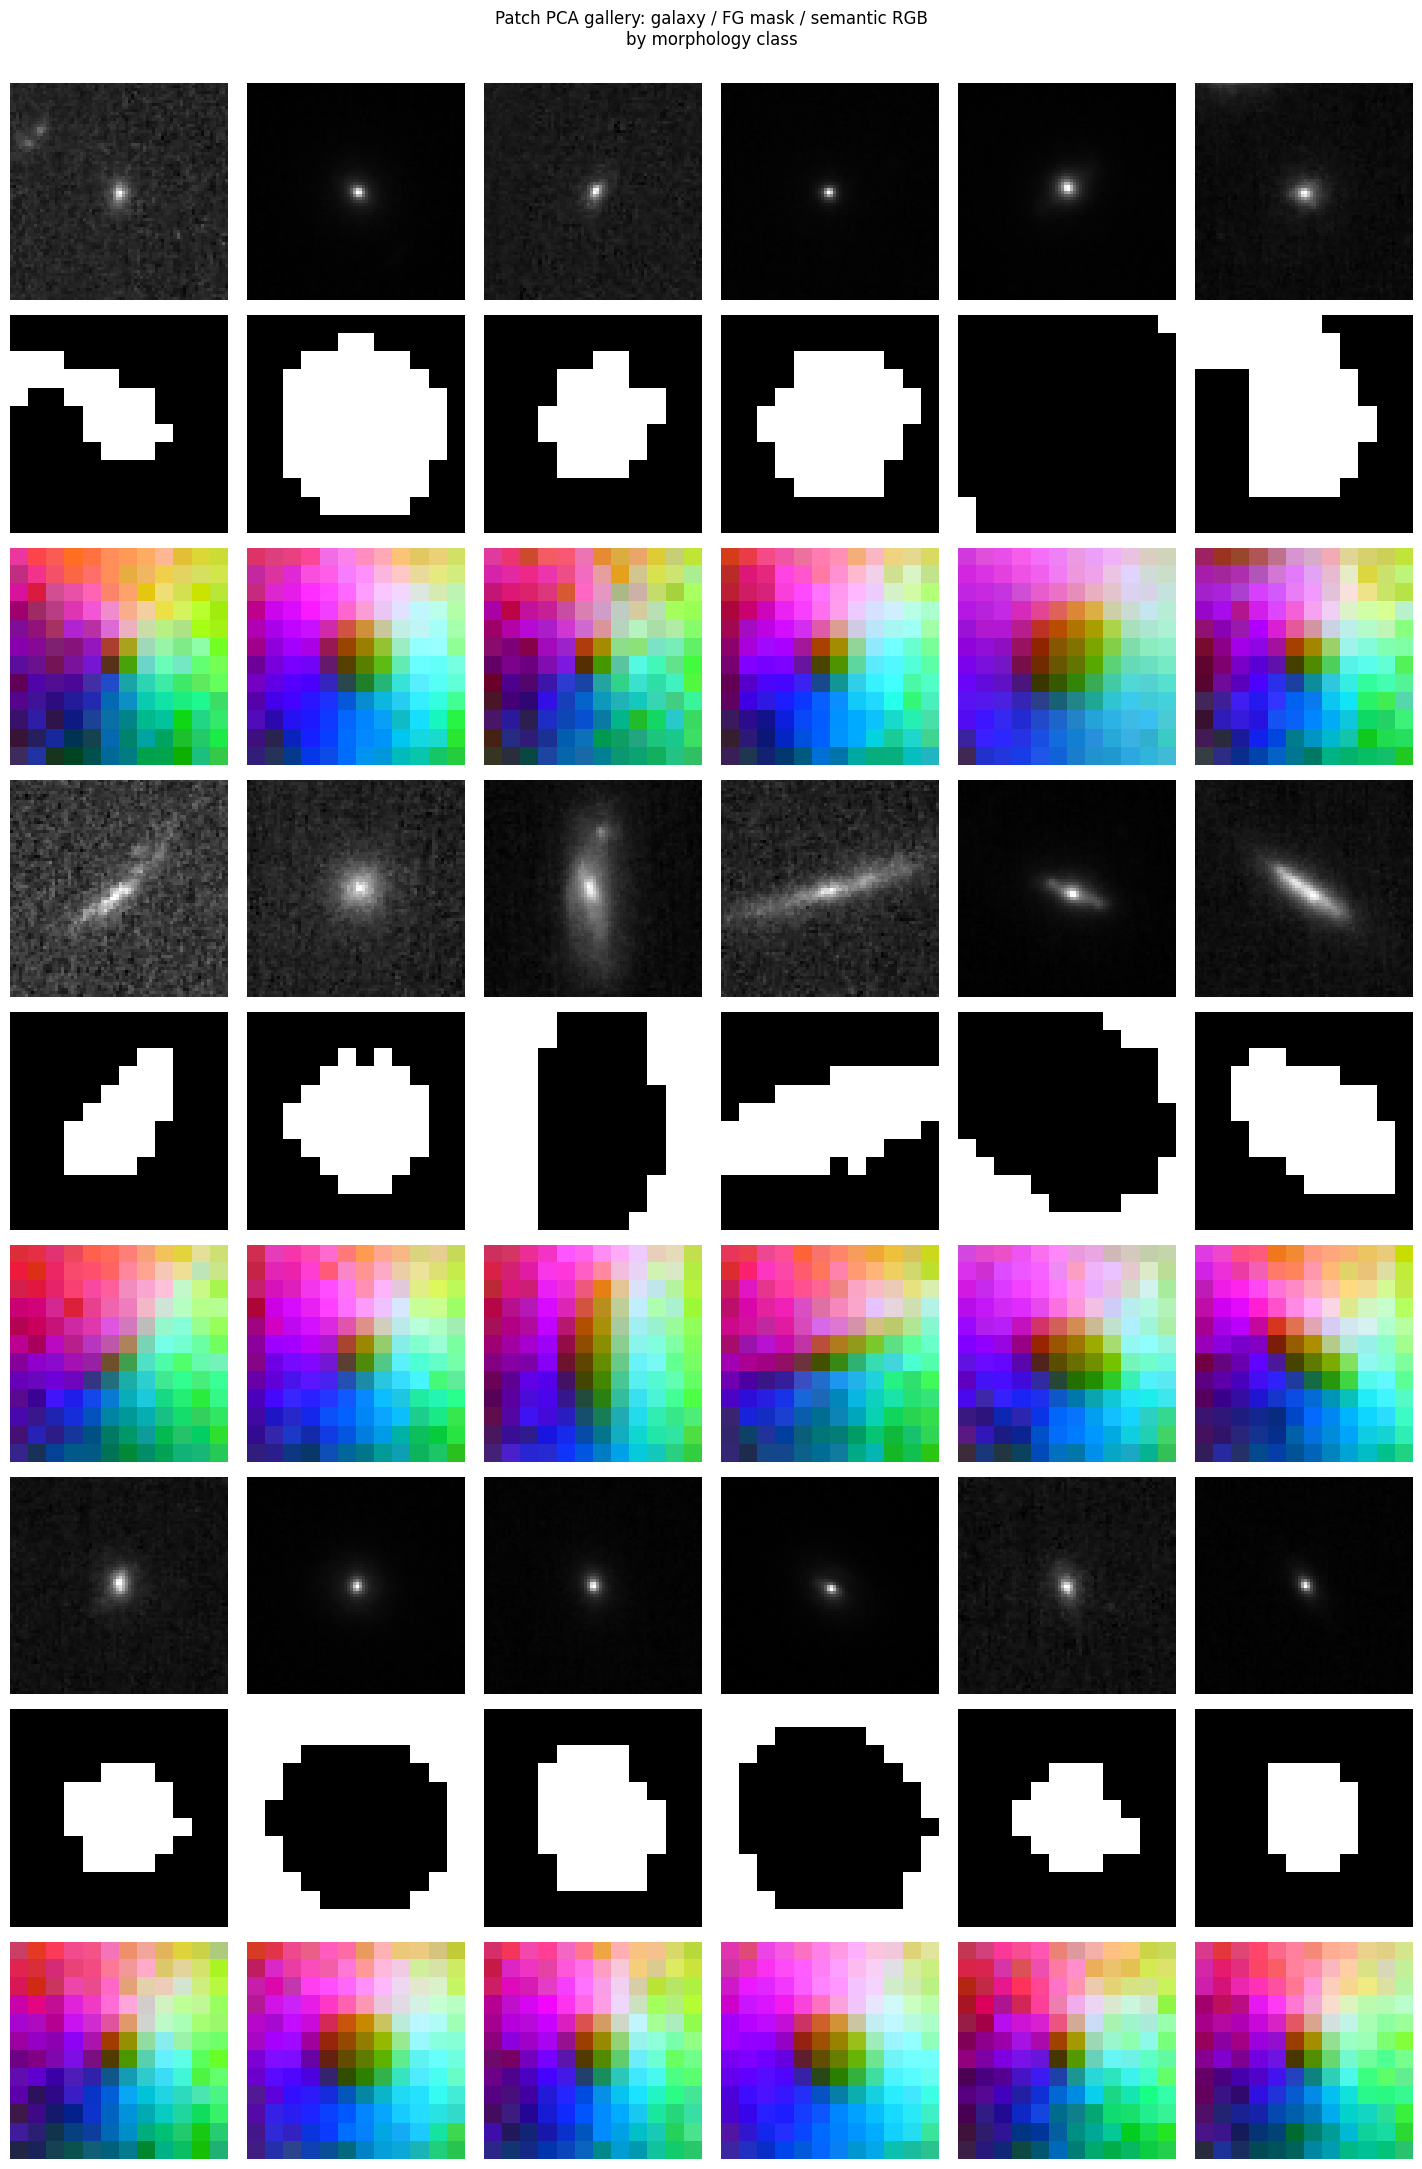

In [23]:
# ── 6c: Gallery — N_GALLERY examples per morphology class ─────────────────────
N_GALLERY = 6
rng_gal   = np.random.default_rng(SEED + 1)

fig, axes = plt.subplots(
    len(present_classes) * 3, N_GALLERY,
    figsize=(2.4 * N_GALLERY, 2.4 * len(present_classes) * 3)
)

for ci, c in enumerate(present_classes):
    class_idx = np.where(morph_all == c)[0]
    chosen    = rng_gal.choice(class_idx, size=min(N_GALLERY, len(class_idx)), replace=False)

    row_base = ci * 3
    for col, gi in enumerate(chosen):
        img     = ds.get_display_image(int(gi))
        grid_i  = pca_grids[gi]
        pc1_g   = grid_i[:, :, 0]
        mask    = make_pc1_mask(pc1_g)
        rgb_map = make_rgb_map_global(grid_i)

        axes[row_base,     col].imshow(img, cmap='gray')
        axes[row_base + 1, col].imshow(mask.astype(float), cmap='Greys_r',
                                       vmin=0, vmax=1, interpolation='nearest')
        axes[row_base + 2, col].imshow(rgb_map, interpolation='nearest')

        for row_off in range(3):
            axes[row_base + row_off, col].axis('off')

    # Row labels
    axes[row_base,     0].set_ylabel(f'{MORPH_NAMES.get(c, c)}\nGalaxy',
                                     fontsize=9, color=MORPH_COLORS[c])
    axes[row_base + 1, 0].set_ylabel('FG mask\n(PC1)', fontsize=9)
    axes[row_base + 2, 0].set_ylabel('Semantic\nRGB', fontsize=9)

plt.suptitle('Patch PCA gallery: galaxy / FG mask / semantic RGB\nby morphology class',
             fontsize=12, y=1.002)
plt.tight_layout()
plt.show()

## 7 · PC1 vs PC2 Scatter in Patch Space

Scatter of individual patches coloured by morphology, effective radius, and axis ratio.
Each point is one patch from one galaxy.
This shows how well the model separates different galaxy properties at the *patch level*.

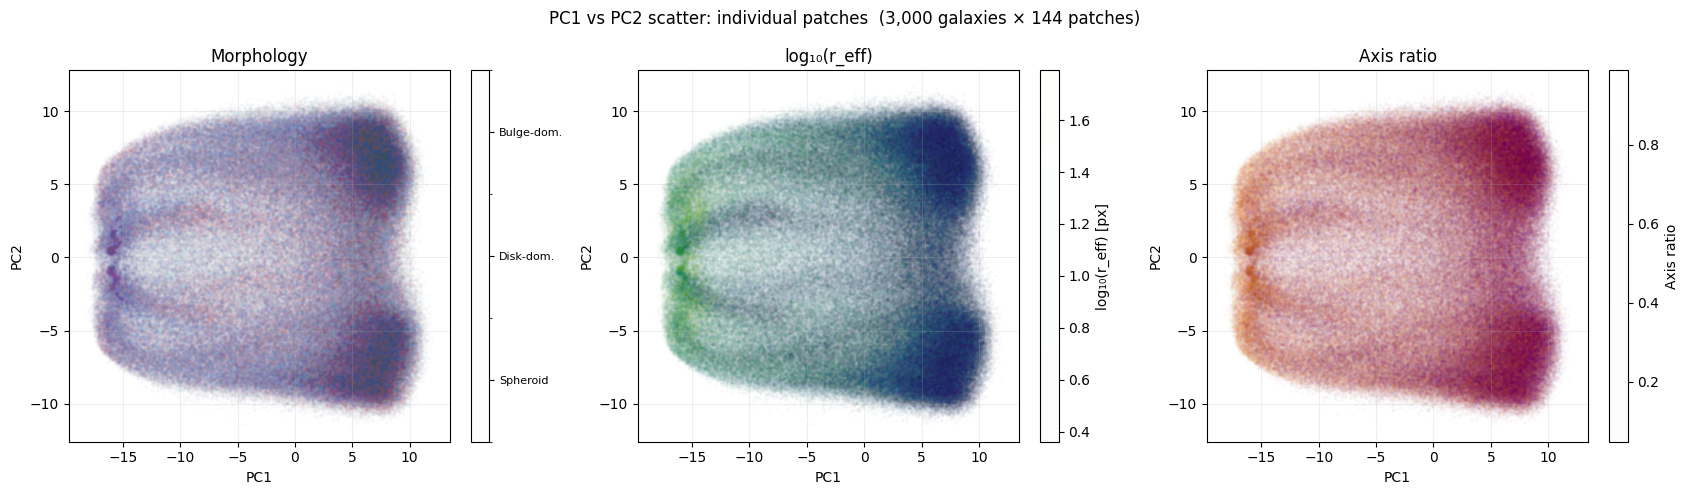

In [24]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# Sub-sample patches for scatter (keep memory manageable)
N_SCATTER_GAL  = min(3000, N)
scatter_gal_idx = rng.choice(N, size=N_SCATTER_GAL, replace=False)

# Gather patch scores and repeat galaxy-level labels N_PATCHES times
pc12_scatter = patches_pca_3d[scatter_gal_idx].reshape(-1, N_COMPONENTS)[:, :2]  # (N_sc*N_p, 2)
morph_scatter = np.repeat(morph_all[scatter_gal_idx], N_PATCHES)
log_re_scatter = np.repeat(log_re_all[scatter_gal_idx], N_PATCHES)
ar_scatter     = np.repeat(ar_all[scatter_gal_idx], N_PATCHES)

cls_remap = {c: i for i, c in enumerate(present_classes)}
morph_scatter_mapped = np.array([cls_remap[v] for v in morph_scatter])

morph_cmap = ListedColormap([MORPH_COLORS[c] for c in present_classes])
morph_norm = BoundaryNorm(np.arange(-0.5, len(present_classes) + 0.5), morph_cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
alpha = min(0.15, 5000 / len(pc12_scatter))

# Panel 1: coloured by morphology
ax = axes[0]
sc = ax.scatter(pc12_scatter[:, 0], pc12_scatter[:, 1],
                c=morph_scatter_mapped, cmap=morph_cmap, norm=morph_norm,
                s=3, alpha=alpha, rasterized=True)
cb = plt.colorbar(sc, ax=ax, ticks=list(range(len(present_classes))), fraction=0.046)
cb.ax.set_yticklabels([MORPH_NAMES[c] for c in present_classes], fontsize=8)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Morphology')
ax.grid(True, alpha=0.2)

# Panel 2: coloured by log10(r_eff)
ax = axes[1]
sc = ax.scatter(pc12_scatter[:, 0], pc12_scatter[:, 1],
                c=log_re_scatter, cmap='viridis',
                s=3, alpha=alpha, rasterized=True)
plt.colorbar(sc, ax=ax, label='log₁₀(r_eff) [px]', fraction=0.046)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('log₁₀(r_eff)')
ax.grid(True, alpha=0.2)

# Panel 3: coloured by axis ratio
ax = axes[2]
sc = ax.scatter(pc12_scatter[:, 0], pc12_scatter[:, 1],
                c=ar_scatter, cmap='plasma',
                s=3, alpha=alpha, rasterized=True)
plt.colorbar(sc, ax=ax, label='Axis ratio', fraction=0.046)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Axis ratio')
ax.grid(True, alpha=0.2)

plt.suptitle(f'PC1 vs PC2 scatter: individual patches  '
             f'({N_SCATTER_GAL:,} galaxies × {N_PATCHES} patches)', fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
ds.close()
print('Done.')

Done.
